## Python For Machine Learning Fall 2025
---
# K-Nearest Neighbors

The K-Nearest Neighbors (KNN) algorithm is a basic and significant machine learning method, valued for its simple concept and straightforward implementation.

`Updated on 10-05 for more examples.`

## 1. The Core Idea

The main idea behind KNN is simple and intuitive: You can predict the characteristics of an unknown data point by looking at the data points that are most similar to it. In other words, things that are close together in "feature space" are likely to be related.

Imagine you're trying to guess the price of a house that's not on the market. You wouldn't look at prices from a different country; you'd look at the prices of the houses right next door on the same street. KNN does the same thing, but with data. It finds the `K` nearest neighbors to a new point and makes a prediction based on them.

## 2. Naïve Example

As a naïve example, we use Numpy to calculate the Euclidean distance between 2D points to find the closest ones. The formula for Euclidean distance is:
$$
d=\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}
$$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Create a dataset
X_train = np.array([
    [2, 3], [4, 2], [5, 4], [7, 3],
    [9, 6], [8, 8], [10, 7], [11, 9]
])
y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1])

To find the category of a new data point, KNN checks the new point's closest neighbors and having them "vote" on its category.

In [ ]:
new_point = np.array([6, 5])

# Calculate distances from the new_point to all training points
distances = np.sqrt(np.sum((X_train - new_point)**2, axis=1))

# Sort the distances and get the original indices
sorted_indices = np.argsort(distances)

print(f"Distances to all points: {np.round(distances, 2)}")
print(f"Indices of neighbors, from closest to farthest: {sorted_indices}")


Distances to all points: [4.47 3.61 1.41 2.24 3.16 3.61 4.47 6.4 ]
Indices of neighbors, from closest to farthest: [2 3 4 1 5 0 6 7]


Although K-Nearest Neighbors is a non-parametric method, it has two hyperparameters: the number of neighbors (`k`) and the distance metric. Since we have already chosen the distance metric, we now need to determine a specific value for `k`.

In [ ]:
k = 3
k_nearest_indices = sorted_indices[:k]
k_nearest_neighbors = X_train[k_nearest_indices]
k_nearest_labels = y_train[k_nearest_indices]

print(f"The new point is: {new_point}")
print(f"The {k} nearest neighbors are at coordinates: \n{k_nearest_neighbors}")
print(f"Their labels are: {k_nearest_labels}")

The new point is: [6 5]
The 3 nearest neighbors are at coordinates: 
[[5 4]
 [7 3]
 [9 6]]
Their labels are: [0 0 1]


Once we've found the 'K' nearest neighbors, what do we do? For classification, the process is **democratic**: we take a vote!

In [ ]:
from collections import Counter

def predict_classification(neighbor_labels):
    vote_counts = Counter(neighbor_labels)
    most_common_label = vote_counts.most_common(1)[0][0]
    return most_common_label

predicted_label = predict_classification(k_nearest_labels)

print(f"New Point: {new_point}")
print(f"Neighbor Labels: {k_nearest_labels}")
print(f"The final prediction is: Class {predicted_label}")

New Point: [6 5]
Neighbor Labels: [0 0 1]
The final prediction is: Class 0


## 3. KNN in `sklearn`

While building KNN from scratch is great for understanding, in practice, we use highly optimized libraries like scikit-learn. It handles the distance calculations and neighbor searching very efficiently, especially for large datasets.

In [ ]:
from sklearn import datasets
iris = datasets.load_iris()
features = iris.data
labels = iris.target
print(features[:3], labels[:3], len(features))

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]] [0 0 0] 150


In [ ]:
# Standardize the features.
from sklearn.preprocessing import StandardScaler

X_std = StandardScaler().fit_transform(features)
print(X_std[:3])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]]


In [ ]:
# Specify the KNN model with two particular hyperparameters.
from sklearn.neighbors import NearestNeighbors

model = NearestNeighbors(n_neighbors=3, metric='euclidean')

model.fit(X_std)

NearestNeighbors(metric='euclidean', n_neighbors=3)

In [ ]:
# Find k neighbors
dinstances, indices = model.kneighbors([[1, 1, 1, 1]])
print(dinstances)
print(indices, labels[indices])

[[0.49140089 0.74294782 0.75692864]]
[[124 110 148]] [[2 2 2]]


## 4. K-Nearest Neighbors Classifier

`sklearn` provides the `KNeighborsClassifier` class for convenient classification using the KNN method.

In [ ]:
# import the dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# preprocessing
standardizer = StandardScaler()
X_std = standardizer.fit_transform(X)

Using `KneighborsClassifier` to create a classifier.

In [ ]:
# Train a KNN classifier with 5 neighbors
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1).fit(X_std, y)

In [ ]:
# Predict the class of two observations
new_observations = [[ 0.75,  0.75,  0.75,  0.75],
                    [ 1,  1,  1,  1]]
knn.predict(new_observations)

array([1, 2])

## 5. K-Nearest Neighbors for Regression

The nearest neighbor principle can also be used for regression. It is based on the idea that similar samples should have similar property values. Therefore, we can predict a target sample's attribute by averaging that attribute's value from its k-nearest neighbors.

In scikit-learn, the KNeighborsRegressor class is used to perform regression.

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

We will now work with the California housing dataset. For ease of visualization, we will use only the median income feature to make our predictions.

In [ ]:
california = fetch_california_housing()
X = california.data[:, california.feature_names.index('MedInc')].reshape(-1, 1)
y = california.target

Split the dataset into training and test sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Preprocessing dataset.

In [ ]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

Create and train a KNN regressor.

In [ ]:
knn_regressor = KNeighborsRegressor(n_neighbors=50)
knn_regressor.fit(X_train_std, y_train)

KNeighborsRegressor(n_neighbors=50)

Now, let's use the trained model to make predictions on the test data.

In [ ]:
y_pred = knn_regressor.predict(X_test_std)

Evaluation.

In [ ]:
mse = mean_squared_error(y_test, y_pred)
print(f"Feature used: {california.feature_names[california.feature_names.index('MedInc')]}")
print(f"MSE: {mse:.4f}")

Feature used: MedInc
MSE: 0.7036


## 6. Weighted k-Nearest Neighbors

The weighted k-Nearest Neighbors (k-NN) algorithm is a modification of the standard k-NN algorithm that assigns weights to the contributions of the neighbors, so that nearer neighbors contribute more to the prediction than more distant ones.
In partical, Instead of treating all 'k' neighbors equally, each neighbor is given a weight. A common and intuitive method is to use the inverse of the distance. This means the closer a neighbor is, the larger its weight. A simple formula for the weight ($w_i$) of the $i$th neighbor at distance ($d_i$) could be:
$$
w_i=\frac{1}{d_i}
$$

Now let's give the weighted KNN model a try. First, let's prepare the dataset.

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

Here we use a new function `make_classification` to generate classification dataset and do some preprocessing.

In [ ]:
X, y = make_classification(n_samples=200, n_features=4, n_informative=2,
                           n_redundant=0, n_classes=2, random_state=42)

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

Then we split the dataset into train and test.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=0.2, random_state=42)

Train a weighted model and a 'uniform' model.

In [ ]:
weighted_knn = KNeighborsClassifier(n_neighbors=7, weights='distance')
weighted_knn.fit(X_train, y_train)

uniform_knn = KNeighborsClassifier(n_neighbors=7, weights='uniform')
uniform_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

Test the models.

In [ ]:
weighted_accuracy = weighted_knn.score(X_test, y_test)
uniform_accuracy = uniform_knn.score(X_test, y_test)

print(f"Weighted kNN Accuracy: {weighted_accuracy}")
print(f"Uniform kNN Accuracy:  {uniform_accuracy}")

Weighted kNN Accuracy: 0.85
Uniform kNN Accuracy:  0.825


## 7. Find the Optimal 'k': Hyperparameter Tuning

The parameter `k` has a significant impact on model performance. The `GridSearchCV` method in `sklearn` can be used to determine the optimal value for `k`.

In [ ]:
# Load libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [ ]:
# Load data
iris = datasets.load_iris()
features = iris.data
target = iris.target

Create a pipeline. Please note that you can assign whatever label to the steps.

In [ ]:
standardizer = StandardScaler()
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

pipe = Pipeline(
    [('standardizer', standardizer),
     ('knn', knn)]
    )

Now we can define what paramerters to search and at what range.

In [ ]:
# Create space of candidate values
search_space = [{"knn__n_neighbors": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}]

# Create grid search
classifier = GridSearchCV(
    pipe,
    search_space,
    cv=5,
    verbose=1).fit(features, target)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Now, let's check what we got from the grid search.

In [ ]:
print(f"The best 'k' value is {classifier.best_params_['knn__n_neighbors']}")
print(f"The best score is {classifier.best_score_}")

The best 'k' value is 6
The best score is 0.9666666666666668


## 8. An Alternative Approach: Radius-based Neighbors
The prediction of KNN might be subtle when the training samples are dense. In this case, distance-based method will be more stable. `sklearn` provide `RadiusNeighborsClassifier` class to create such classifiers.

In [ ]:
from sklearn.neighbors import RadiusNeighborsClassifier
rnn = RadiusNeighborsClassifier(
    radius=.5,
    n_jobs=-1).fit(X_std, y)

new_observations = [[ 1,  1,  1,  1]]

rnn.predict(new_observations)

array([1])

One potential problem with distance-based classifiers is that no targets may be found within the specified radius.

In [ ]:
X_train = np.array([
    [1, 1], [1, 2], [2, 1], [2, 2], # Cluster 0
    [10, 10], [10, 11], [11, 10], [11, 11] # Cluster 1
])
y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1])

Here we use `outlier_label` to identify points with no neighbors.

In [ ]:
rnn = RadiusNeighborsClassifier(
    radius=2.0,
    outlier_label=-1)
rnn.fit(X_train, y_train)

RadiusNeighborsClassifier(outlier_label=-1, radius=2.0)

In [ ]:
new_points = np.array([
    [1.5, 1.5], # Should be classified as 0
    [6.0, 6.0]  # Should be an outlier
])

predictions = rnn.predict(new_points)
print(f"Predictions: {predictions}")

Predictions: [ 0 -1]


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:864: UserWarning: Outlier label -1 is not in training classes. All class probabilities of outliers will be assigned with 0.
  warnings.warn(


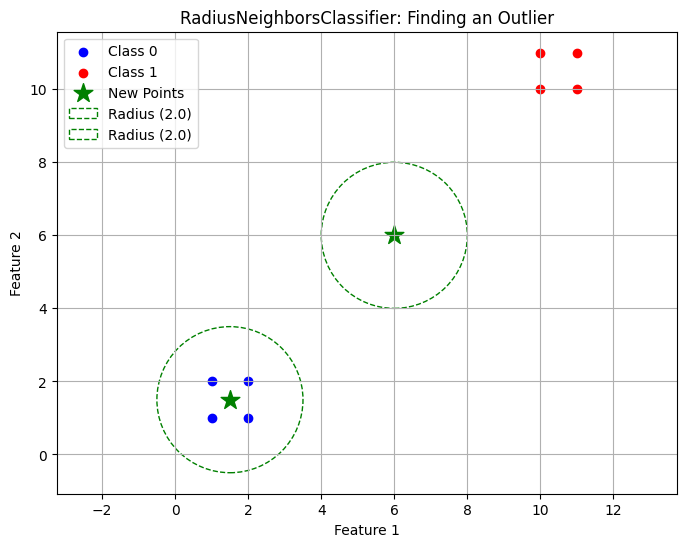

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train==0][:, 0],
            X_train[y_train==0][:, 1],
            c='blue',
            label='Class 0')
plt.scatter(X_train[y_train==1][:, 0],
            X_train[y_train==1][:, 1],
            c='red',
            label='Class 1')
plt.scatter(new_points[:, 0],
            new_points[:, 1],
            c='green',
            marker='*',
            s=200,
            label='New Points')

# Draw circles for the radius around the new points
for point in new_points:
    circle = plt.Circle(
        point, 2.0,
        color='green',
        fill=False,
        linestyle='--',
        label='Radius (2.0)')
    plt.gca().add_patch(circle)

plt.title("RadiusNeighborsClassifier: Finding an Outlier")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

## 8. Approximate Nearest Neighbors

The KNN method is computationally costly when we have a large dataset. There are variations of algorithms to solve this problem. Divide and conquer is a typically effective method. Here, we will use Facebook's FAISS library to do an experiment. FAISS (Facebook AI Similarity Search) is an open-source library for similarity search and clustering of vectors. It contains algorithms that search in sets of vectors of any size, up to ones that possibly do not fit in RAM.

In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 60.6 MB/s eta 0:00:00


Now we can set the parameters for FAISS.

In [ ]:
n_features = X_std.shape[1]
nlist = 3
k = 2

In [ ]:
import faiss

quantizer = faiss.IndexFlatIP(n_features)
index = faiss.IndexIVFFlat(quantizer, n_features, nlist)

# Train the index and add feature vectors
index.train(X_std)
index.add(X_std)

# Create an observation
new_observation = np.array([[ 1,  1,  1,  1]])

# Search the index for the 2 nearest neighbors
distances, indices = index.search(new_observation, k)

# Show the feature vectors for the two nearest neighbors
np.array([list(X_std[i]) for i in indices[0]])

array([[0.90321861, 0.6633022 , 1.00109035, 0.95330983],
       [0.52212016, 1.68934088, 1.04278479, 1.05106782]])

Now let's see how FAISS works.

In [ ]:
# import packages
import numpy as np
import faiss
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.datasets import make_blobs

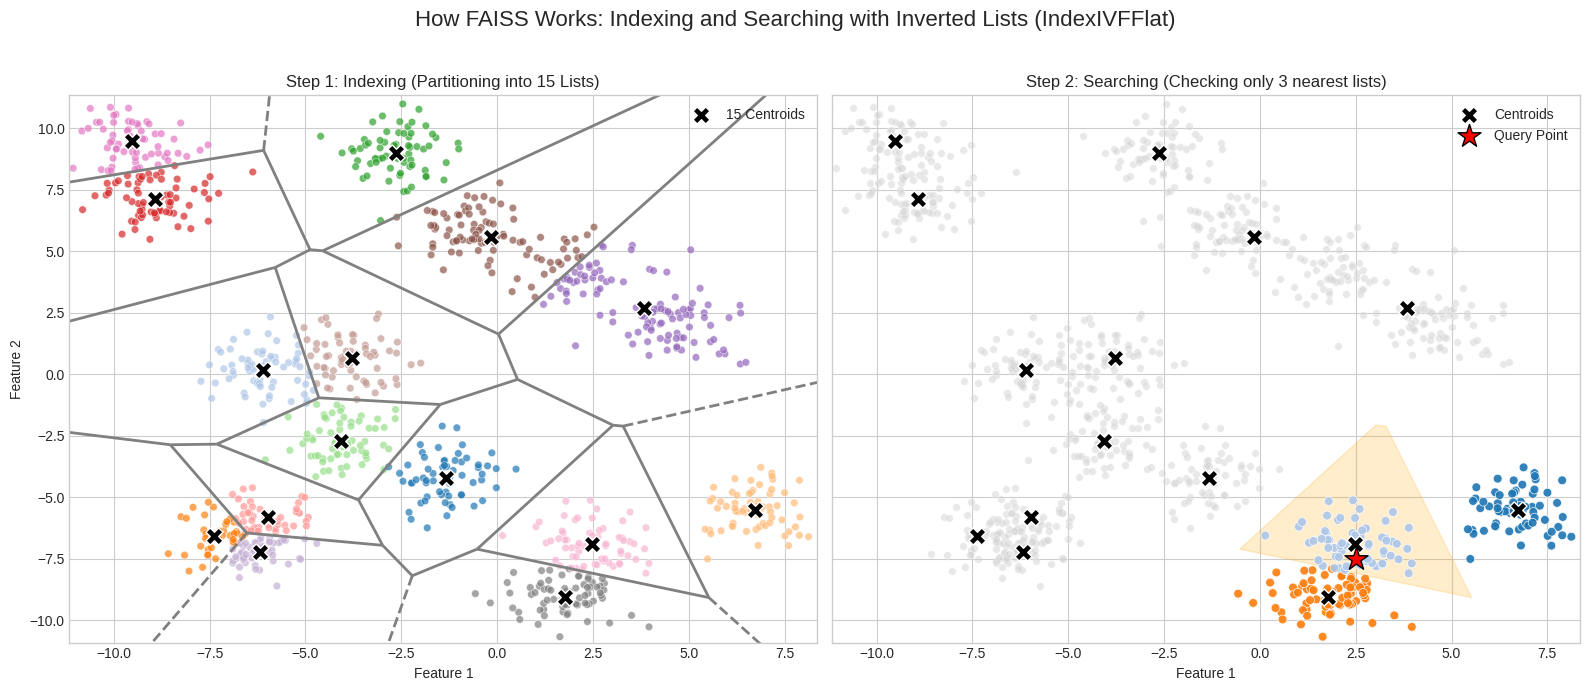

In [ ]:
np.random.seed(42)
X, y = make_blobs(n_samples=1000, centers=15, n_features=2, random_state=42, cluster_std=0.8)
X = X.astype('float32') # FAISS requires float32

D = X.shape[1] # Dimensions
N = X.shape[0] # Number of samples


nlist = 15 # centers
quantizer = faiss.IndexFlatL2(D)
index = faiss.IndexIVFFlat(quantizer, D, nlist, faiss.METRIC_L2)

# Train the index to find the nlist centroids
index.train(X)
index.add(X)

centroids = index.quantizer.reconstruct_n(0, nlist)

_, list_ids = quantizer.search(X, 1)
list_ids = list_ids.flatten()

query_point = np.array([[2.5, -7.5]], dtype='float32')
nprobe = 3

distances, cell_ids = quantizer.search(query_point, nprobe)
probed_cell_ids = cell_ids.flatten()

# Create the Visualization ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
fig.suptitle("How FAISS Works: Indexing and Searching with Inverted Lists (IndexIVFFlat)", fontsize=16)

ax1.set_title(f"Step 1: Indexing (Partitioning into {nlist} Lists)", fontsize=12)
vor = Voronoi(centroids)
voronoi_plot_2d(vor, ax=ax1, show_vertices=False, line_colors='gray', line_width=2, point_size=0)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=list_ids, palette='tab20', ax=ax1, s=30, alpha=0.7, legend=False)
ax1.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=150, edgecolor='white', label=f'{nlist} Centroids')
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")
ax1.legend()

ax2.set_title(f"Step 2: Searching (Checking only {nprobe} nearest lists)", fontsize=12)

for region_index in probed_cell_ids:
    region = vor.regions[vor.point_region[region_index]]
    if not -1 in region:
        polygon = [vor.vertices[i] for i in region]
        ax2.fill(*zip(*polygon), alpha=0.2, color='orange', edgecolor='orange')

# Plot all data points faintly
sns.scatterplot(x=X[:, 0], y=X[:, 1], color='lightgray', ax=ax2, s=30, alpha=0.5)

# Highlight data points within the searched cells
searched_points_mask = np.isin(list_ids, probed_cell_ids)
sns.scatterplot(x=X[searched_points_mask, 0], y=X[searched_points_mask, 1], hue=list_ids[searched_points_mask], palette='tab20', ax=ax2, s=40, alpha=0.9, legend=False)
ax2.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=150, edgecolor='white', label='Centroids')
ax2.scatter(query_point[:, 0], query_point[:, 1], c='red', marker='*', s=300, edgecolor='black', label='Query Point')
ax2.set_xlabel("Feature 1")
ax2.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 9. Summarization

As one of the most classic algorithms in machine learning, the K-Nearest Neighbors (KNN) method has both advantages and disadvantages, even though it does not have a distinct "learning" phase.
Pros:
- Simple and intuitive
- Non-parametric
- No training phase (lazy learner)

Cons:
- Computationally expensive
- Curse of Dimensionality
- Sensitive to feature scaling
- Requires large memory

Further Reading: https://contrib.scikit-learn.org/metric-learn/auto_examples/plot_metric_learning_examples.html#sphx-glr-auto-examples-plot-metric-learning-examples-py